In [ ]:
# === Google Colab 自動環境セットアップ ===
# ※ローカル環境では無視され、Colab環境でのみ自動でモジュールをインストールします
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/my_DeepLearning'):
        print("リポジトリをダウンロード中...")
        !git clone https://github.com/miyayudai/my_DeepLearning.git > /dev/null 2>&1
    
    print("必要なモジュールをインストール中...")
    %cd /content/my_DeepLearning
    !pip install -q -r requirements.txt
    !pip install -q -e .
    
    print("作業ディレクトリをセットアップ中...")
    %cd /content/my_DeepLearning/6
    print("準備完了！このまま下のセルを実行できます。")

# 第6章 深層ニューラルネットワーク (Deep Neural Networks)
## 6.1 固定基底関数の限界 (Limitations of Fixed Basis Functions)

### 本節の概要と位置づけ
前章（第4章・第5章）では、固定された非線形基底関数 $\phi_j(\mathbf{x})$ の線形結合に基づく回帰モデルおよび分類モデルを考察しました：
$$
y(\mathbf{x}, \mathbf{w}) = f\left( \sum_{j=1}^M w_j \phi_j(\mathbf{x}) + w_0 \right) \tag{6.1}
$$
これらは、重みとバイアスが1層のみの**単層ニューラルネットワーク (Single-layer Networks)** とみなすことができます。数学的には、適切に選ばれた十分な数の基底関数があれば、任意の非線形関数を所望の精度で近似（普遍近似）できるため、一見すると機械学習のあらゆる問題に対する汎用フレームワークとして十分であるように思われます。

しかし、これらの線形モデルには**重大な根本的限界**が存在します。その原因は、**基底関数 $\phi_j(\mathbf{x})$ が訓練データとは無関係に事前に固定されている**という仮定にあります。入力空間の次元数 $D$ が増加すると、固定基底関数モデルは直ちに破綻します。

本節では、以下の4つの観点から固定基底関数の限界を明らかにし、なぜデータから適応的に特徴を学習する**深層ニューラルネットワーク (Deep Neural Networks)** が不可欠であるのかを解明します：

1. **6.1.1 次元の呪い (The curse of dimensionality)**: 多項式モデルのパラメータ数爆発 $O(D^M)$、グリッド分割による空間セル数の指数的爆発 $K^D$、Irisデータによる検証 (Figure 6.1, 6.2, 6.3)
2. **6.1.2 高次元空間の幾何学的性質 (High-dimensional spaces)**: 超球の体積が表面の極薄い殻に集中する現象 $1 - (1-\epsilon)^D$ (Figure 6.4)、多変量ガウス分布の確率質量が半径 $r \approx \sqrt{D}\sigma$ の薄い球殻に集中する現象 (Figure 6.5)、高次元空間がもたらす線形分離性の利点 (Figure 6.6)
3. **6.1.3 データ多様体 (Data manifolds)**: 実データが埋め込まれた低次元多様体（手書き数字画像の3自由度多様体、Figure 6.7）、画素解像度と真の次元、自然画像と無相関一様ノイズ画像の対比 (Figure 6.8)
4. **6.1.4 データ依存の基底関数 (Data-dependent basis functions)**: 手作業の特徴量設計の限界、動径基底関数 (RBF, Eq 6.6)、サポートベクトルマシン (SVM)、そして階層的に表現を学習する深層学習へのパラダイムシフト


In [1]:
# 環境セットアップと共通モジュールの読み込み
import os
import sys
import numpy as np
import scipy.special as special
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# プロジェクトルートの設定
current_dir = os.getcwd()
if os.path.basename(current_dir) == '6':
    repo_root = os.path.abspath(os.path.join(current_dir, '..'))
else:
    repo_root = os.path.abspath(current_dir)

if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from common.plot_utils import setup_style, save_plot
from common.basis_limitations import (
    polynomial_feature_count,
    grid_cell_count,
    hypersphere_volume_shell_fraction,
    gaussian_radial_density,
    gaussian_radial_mode,
    GridClassifier,
    RadialBasisFunctions,
    generate_all_section_6_1_figures,
    generate_figure_6_1,
    generate_figure_6_2,
    generate_figure_6_3,
    generate_figure_6_4,
    generate_figure_6_5,
    generate_figure_6_6,
    generate_figure_6_7,
    generate_figure_6_8
)

setup_style()
print("第6章 6.1節 環境セットアップが完了しました。")


第6章 6.1節 環境セットアップが完了しました。


---
## 6.1.1 次元の呪い (The Curse of Dimensionality)

### 1. 多項式回帰モデルにおける次元の増大
1変数の $M$ 次多項式回帰モデル (式 1.1, 1.2) は次式で与えられます：
$$
y(x, \mathbf{w}) = w_0 + w_1 x + w_2 x^2 + \dots + w_M x^M \tag{6.2}
$$
このモデルの係数数は $M + 1$ 個に過ぎません。しかし、入力変数が $D$ 個 $\mathbf{x} = (x_1, \dots, x_D)^T$ に増加した場合、3次までの一般多項式は次のようになります：
$$
y(\mathbf{x}, \mathbf{w}) = w_0 + \sum_{i=1}^D w_i x_i + \sum_{i=1}^D \sum_{j=1}^D w_{ij} x_i x_j + \sum_{i=1}^D \sum_{j=1}^D \sum_{k=1}^D w_{ijk} x_i x_j x_k \tag{6.3}
$$
ここで、$w_{ij} = w_{ji}$ などの対称性を考慮した独立な係数の総数は、重複組合せにより厳密に与えられます：
$$
N_{\text{params}} = \binom{D + M}{M} = \frac{(D + M)!}{D! M!}
$$
- $M = 3$ のとき、係数の数は $O(D^3)$ で増加します。
- 一般の $M$ 次多項式では、係数の総数は $O(D^M)$ という**入力次元のべき乗で急激に爆発**します。例えば $D = 100, M = 3$ のとき、パラメータ数は $\binom{103}{3} = 176,851$ 個に達し、実用的な学習・汎化は著しく困難になります。

このように、次元数の増大に伴って空間の体積や探索空間が指数関数的・多項式的に増大し、問題の複雑さが爆発する現象を**次元の呪い (Curse of Dimensionality)**（Bellman, 1961）と呼びます。

### 2. グリッド分割による局所分類器とその破綻
分類問題において、「未知のテスト点 $\mathbf{x}$ のクラスは、その近傍にある訓練データによって決定されるべきである」という直感は極めて自然です。
この直感を最も素朴にアルゴリズム化したものが、入力空間を規則的な格子（セル）に分割する手法です (Figure 6.1, 6.2)。


Figure saved successfully to: result/fig_6_1_iris_data.png
Figure saved successfully to: 6/result/fig_6_1_iris_data.png


Figure saved successfully to: result/fig_6_2_grid_partitioning.png


Figure saved successfully to: 6/result/fig_6_2_grid_partitioning.png


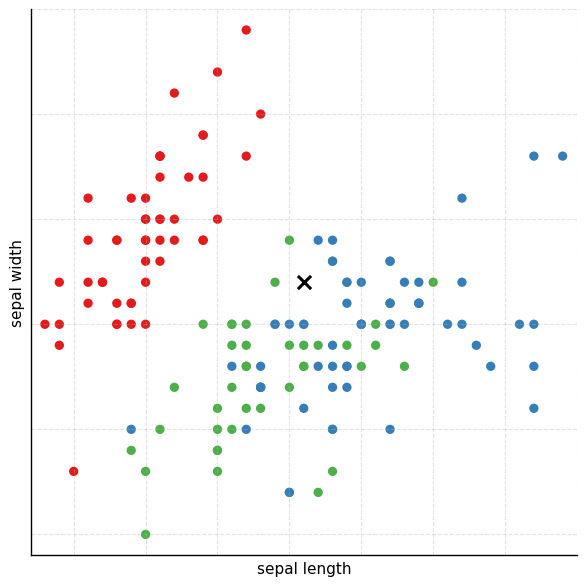

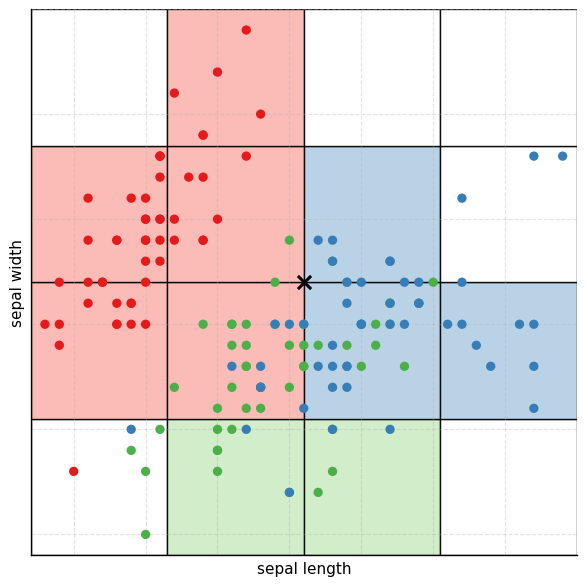

訓練データ有効セル内 精度: 78.7%
未分類（データなし）セル数: 4 / 16


In [2]:
# Figure 6.1 & Figure 6.2: Irisデータセットの散布図と規則的グリッド分割分類器
fig_6_1 = generate_figure_6_1(result_dirs=["result", "6/result"])
fig_6_2 = generate_figure_6_2(result_dirs=["result", "6/result"])
plt.show()

# グリッド分類器の自己検証
iris = load_iris()
X_iris = iris.data[:, :2]
y_iris = iris.target

grid_clf = GridClassifier(x_bins=4, y_bins=4)
grid_clf.fit(X_iris, y_iris)
preds = grid_clf.predict(X_iris)

valid = (preds >= 0)
acc = np.mean(preds[valid] == y_iris[valid])
print(f"訓練データ有効セル内 精度: {acc * 100:.1f}%")
print(f"未分類（データなし）セル数: {np.sum(grid_clf.grid_classes == -1)} / {4 * 4}")


### 3. グリッド分割におけるセル数の指数的爆発 (Figure 6.3)
Figure 6.2 の手法の最も致命的な欠陥は、空間の次元 $D$ を増やしたときに現れます。
各軸を $K$ 個の区間に分割した場合、全空間のセルの総数は：
$$
N_{\text{cells}} = K^D
$$
と**次元 $D$ に対して指数関数的に爆発**します (Figure 6.3)：
- $D = 1$ のとき：$3^1 = 3$ 個
- $D = 2$ のとき：$3^2 = 9$ 個
- $D = 3$ のとき：$3^3 = 27$ 個
- $D = 10$ のとき：$3^{10} = 59,049$ 個
- $D = 100$ のとき：$3^{100} \approx 5.15 \times 10^{47}$ 個

各セルに少なくとも1つの訓練データが存在するためには、次元数に対して指数関数的に多くのデータが必要となります。高次元空間では、ほとんどすべてのセルが空（データ数 0）となり、局所的な固定基底関数による推定は完全に崩壊します。


Figure saved successfully to: result/fig_6_3_curse_of_dimensionality_grid.png


Figure saved successfully to: 6/result/fig_6_3_curse_of_dimensionality_grid.png


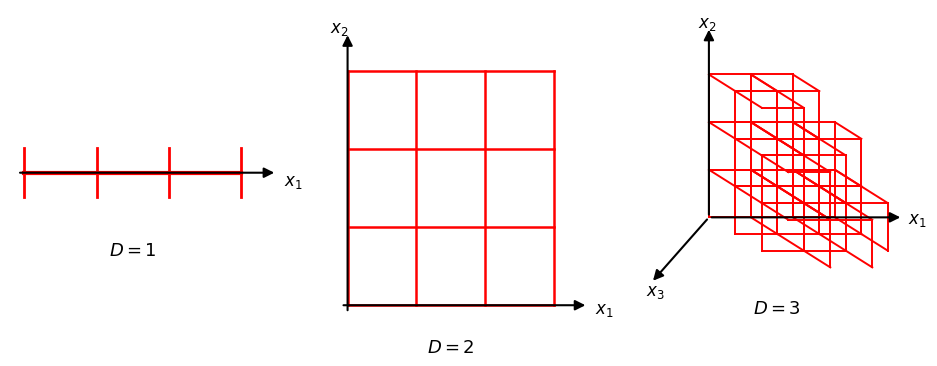

=== 多項式モデルのパラメータ数 O(D^M) ===
次元 D =   1, 3次多項式パラメータ数:          4
次元 D =   2, 3次多項式パラメータ数:         10
次元 D =   5, 3次多項式パラメータ数:         56
次元 D =  10, 3次多項式パラメータ数:        286
次元 D =  50, 3次多項式パラメータ数:      23426
次元 D = 100, 3次多項式パラメータ数:     176851

=== グリッド分割のセル数 K^D (K=3) ===
次元 D =  1, セル総数:            3
次元 D =  2, セル総数:            9
次元 D =  3, セル総数:           27
次元 D =  5, セル総数:          243
次元 D = 10, セル総数:        59049
次元 D = 20, セル総数:   3486784401


In [3]:
# Figure 6.3: 次元の呪い（空間領域数の指数的増加 D=1, 2, 3）
fig_6_3 = generate_figure_6_3(result_dirs=["result", "6/result"])
plt.show()

# パラメータ数とセル数のスケーリング計算
print("=== 多項式モデルのパラメータ数 O(D^M) ===")
for D in [1, 2, 5, 10, 50, 100]:
    cnt = polynomial_feature_count(D, M=3)
    print(f"次元 D = {D:3d}, 3次多項式パラメータ数: {cnt:10d}")

print("\n=== グリッド分割のセル数 K^D (K=3) ===")
for D in [1, 2, 3, 5, 10, 20]:
    cells_cnt = grid_cell_count(num_intervals_per_dim=3, D=D)
    print(f"次元 D = {D:2d}, セル総数: {cells_cnt:12d}")


---
## 6.1.2 高次元空間の幾何学的性質 (High-Dimensional Spaces)

人間は3次元空間で生活しているため、その幾何学的直感は高次元空間においてしばしば著しく破綻します。

### 1. 超球の体積集中現象 (Figure 6.4)
$D$ 次元空間における半径 $r$ の超球の体積 $V_D(r)$ は、$r^D$ に比例します：
$$
V_D(r) = K_D r^D \tag{6.4}
$$
ここで比例定数 $K_D = \frac{\pi^{D/2}}{\Gamma(D/2 + 1)}$ は次元 $D$ のみに依存します。
半径 $r = 1$ の超球において、表面近傍の薄い殻 $r \in [1 - \epsilon, 1]$ に含まれる体積の割合は：
$$
\frac{V_D(1) - V_D(1 - \epsilon)}{V_D(1)} = \frac{K_D \cdot 1^D - K_D (1 - \epsilon)^D}{K_D \cdot 1^D} = 1 - (1 - \epsilon)^D \tag{6.5}
$$
となります。
- $D$ が大きいとき、任意の $\epsilon > 0$ に対して $(1 - \epsilon)^D \to 0$ と急速に減衰します。
- したがって、$1 - (1 - \epsilon)^D \to 1$ となり、**超球の体積のほぼすべてが表面直下の極めて薄い球殻に集中する**という驚くべき結論が得られます (Figure 6.4)。


Figure saved successfully to: result/fig_6_4_hypersphere_volume_fraction.png


Figure saved successfully to: 6/result/fig_6_4_hypersphere_volume_fraction.png


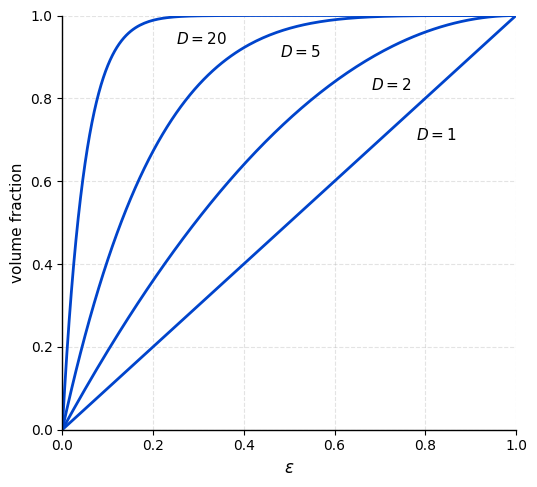

D =   1: 外側5%の球殻 (r in [0.95, 1.0]) に存在する体積比率 =   5.00%
D =   2: 外側5%の球殻 (r in [0.95, 1.0]) に存在する体積比率 =   9.75%
D =   5: 外側5%の球殻 (r in [0.95, 1.0]) に存在する体積比率 =  22.62%
D =  20: 外側5%の球殻 (r in [0.95, 1.0]) に存在する体積比率 =  64.15%
D =  50: 外側5%の球殻 (r in [0.95, 1.0]) に存在する体積比率 =  92.31%
D = 100: 外側5%の球殻 (r in [0.95, 1.0]) に存在する体積比率 =  99.41%


In [4]:
# Figure 6.4: 超球の体積比率 1 - (1 - eps)^D
fig_6_4 = generate_figure_6_4(result_dirs=["result", "6/result"])
plt.show()

# 数値検証: 各次元における eps = 0.05 (外側5%の殻) の体積割合
for D in [1, 2, 5, 20, 50, 100]:
    frac = hypersphere_volume_shell_fraction(0.05, D)
    print(f"D = {D:3d}: 外側5%の球殻 (r in [0.95, 1.0]) に存在する体積比率 = {frac * 100:6.2f}%")


### 2. 高次元ガウス分布の球殻集中現象 (Figure 6.5)
機械学習において中心的な役割を果たす多変量ガウス分布 $\mathcal{N}(\mathbf{x} \mid \mathbf{0}, \sigma^2 \mathbf{I})$ を考えます：
$$
p(\mathbf{x}) = \frac{1}{(2\pi \sigma^2)^{D/2}} \exp\left( -\frac{\|\mathbf{x}\|^2}{2\sigma^2} \right) \tag{6.57}
$$
直感的には原点 $\mathbf{x} = \mathbf{0}$ において確率密度 $p(\mathbf{x})$ が最大であるため、原点近傍にデータが集まると思われがちです。
しかし、極座標変換を行い方向成分を積分消去すると、原点からの動径 $r$ に関する確率密度 $p(r)$（すなわち厚み $\delta r$ の薄い殻の確率質量 $p(r) \delta r$）は：
$$
p(r) = \frac{S_D r^{D-1}}{(2\pi \sigma^2)^{D/2}} \exp\left( -\frac{r^2}{2\sigma^2} \right) \tag{6.58}
$$
となります。ここで $S_D = \frac{2\pi^{D/2}}{\Gamma(D/2)}$ は $D$ 次元単位超球の表面積です。
対数微分をとると：
$$
\frac{d}{dr}\ln p(r) = \frac{D - 1}{r} - \frac{r}{\sigma^2} = 0 \implies \hat{r} = \sqrt{D - 1} \, \sigma \approx \sqrt{D} \sigma
$$
最頻値 $\hat{r}$ の近傍でテイラー展開すると（Exercise 6.3）：
$$
p(\hat{r} + \epsilon) = p(\hat{r}) \exp\left( -\frac{\epsilon^2}{\sigma^2} \right) \tag{6.59}
$$
となり、動径の広がり（標準偏差）は次元 $D$ に依存せず $O(\sigma)$ の一定幅にとどまります。
したがって、相対的な殻の厚みは：
$$
\frac{\sigma}{\hat{r}} \approx \frac{1}{\sqrt{D}} \to 0 \quad (D \to \infty)
$$
となり、**高次元空間ではガウス分布の確率質量のほぼ100%が半径 $\hat{r} \approx \sqrt{D}\sigma$ の極薄の球殻（いわゆるソープバブル）上に集中する**ことが分かります (Figure 6.5)。


Figure saved successfully to: result/fig_6_5_gaussian_radial_density.png


Figure saved successfully to: 6/result/fig_6_5_gaussian_radial_density.png


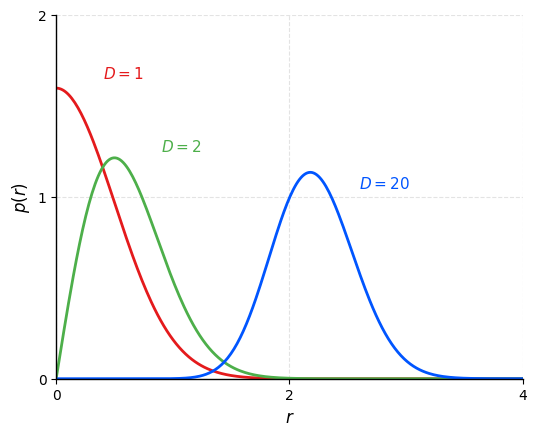

=== ガウス動径密度の最頻値と積分規格化 (sigma = 0.5) ===
次元 D =  1: 最頻値半径 r_hat = 0.0000, 全空間積分 = 1.000000
次元 D =  2: 最頻値半径 r_hat = 0.5000, 全空間積分 = 1.000000
次元 D =  5: 最頻値半径 r_hat = 1.0000, 全空間積分 = 1.000000
次元 D = 20: 最頻値半径 r_hat = 2.1794, 全空間積分 = 1.000000


In [5]:
# Figure 6.5: 高次元ガウス分布の動径確率密度 p(r)
fig_6_5 = generate_figure_6_5(result_dirs=["result", "6/result"])
plt.show()

# 各次元における最頻値半径 r_hat の理論値と正規化密度の数値積分検証
import scipy.integrate as integrate

print("=== ガウス動径密度の最頻値と積分規格化 (sigma = 0.5) ===")
for D in [1, 2, 5, 20]:
    mode_r = gaussian_radial_mode(D, sigma=0.5)
    integral, _ = integrate.quad(lambda r: gaussian_radial_density(r, D=D, sigma=0.5), 0.0, 15.0)
    print(f"次元 D = {D:2d}: 最頻値半径 r_hat = {mode_r:.4f}, 全空間積分 = {integral:.6f}")


### 3. 高次元空間がもたらす利点 (Figure 6.6)
「次元の呪い」は深刻な計算量爆発をもたらす一方で、高次元空間には**機械学習上の大きな利点**も存在します。
Figure 6.6 に示すように：
- 1次元の部分空間 $x_1$ に射影されたデータでは、2つのクラスが激しく重複し、線形分離は不可能です。
- しかし、もう1つの次元 $x_2$ を加えた2次元空間 $(x_1, x_2)$ では、同一のデータ点が**超平面によって完全に線形分離可能**になります。

より高次元の特徴空間へ写像することによって、低次元では複雑に絡み合ったパターンが線形分離可能になるという性質は、Coverの定理（1965）として知られ、カーネル法やニューラルネットワークの隠れ層の基本原理となっています。


Figure saved successfully to: result/fig_6_6_dimension_projection_separability.png


Figure saved successfully to: 6/result/fig_6_6_dimension_projection_separability.png


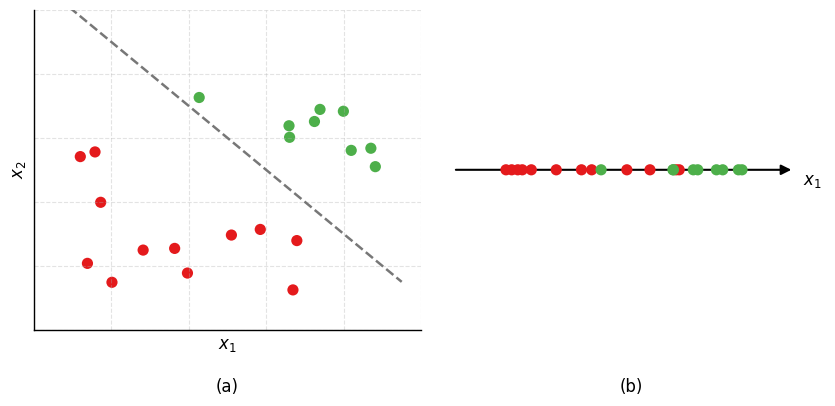

In [6]:
# Figure 6.6: 高次元化による線形分離可能性の向上
fig_6_6 = generate_figure_6_6(result_dirs=["result", "6/result"])
plt.show()


---
## 6.1.3 データ多様体 (Data Manifolds)

高次元空間における次元の呪いは絶望的に思えるかもしれませんが、現実の深層学習アプリケーション（画像認識、音声認識、自然言語処理など）が数十万〜数億次元の空間で見事に成功しているのはなぜでしょうか？

その最大の理由は、**現実世界のデータが高次元空間全体に均一に広がることは決してなく、はるかに低い「内在的次元 (Intrinsic Dimensionality)」を持つ非線形な「データ多様体 (Data Manifold)」上に局在しているから**です。

### 1. 手書き数字画像に見る多様体の構造 (Figure 6.7)
例えば、$28 \times 28$ 画素の手書き数字画像は $D = 784$ 次元の空間の点です。
しかし、数字「5」の画像が変動する要因（自由度）を物理的に考えると：
1. 画像内での水平方向の平行移動 ($\Delta x$)
2. 垂直方向の平行移動 ($\Delta y$)
3. 回転角度 ($	heta$)

というわずか **3つの連続的自由度** です (Figure 6.7)。したがって、これらの画像群は 784 次元空間の中に埋め込まれた **本質的に3次元の非線形多様体** 上に存在しています。画素数を $100 \times 100 = 10,000$ 次元に高解像度化しても、この本質的な3次元多様体という事実は一切変わりません。

もし基底関数を高次元空間全体に格子状に配置するのではなく、**データ多様体の上に沿って局所的に配置**することができれば、必要な基底関数の数は空間の次元 $D$ ではなく、多様体の次元 $d \ll D$ の指数関数 $O(K^d)$ で済み、次元の呪いを劇的に回避できます。


Figure saved successfully to: result/fig_6_7_digit_manifold.png


Figure saved successfully to: 6/result/fig_6_7_digit_manifold.png


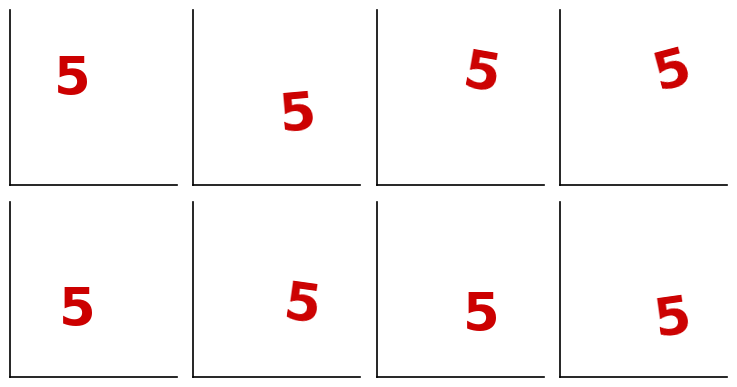

In [7]:
# Figure 6.7: 平行移動と回転の自由度をもつ手書き数字多様体
fig_6_7 = generate_figure_6_7(result_dirs=["result", "6/result"])
plt.show()


### 2. 自然画像と一様ランダムノイズ画像の対比 (Figure 6.8)
実データが高次元空間の極めて狭い部分多様体に局在していることは、ランダム画像との対比からも極めて明瞭に理解できます。
$64 \times 64 \times 3 = 12,288$ 次元の画像空間を考えます：
- 各画素の RGB 値を $[0, 1]$ の一様分布から互いに独立にサンプリングして生成した画像 (Figure 6.8 下段) は、完全な「砂嵐（ホワイトノイズ）」となり、自然画像には微塵も似ていません。
- 自然画像 (Figure 6.8 上段) は、隣接する画素同士が極めて強く相関しており、滑らかな輪郭線やテクスチャを形成しています。

$12,288$ 次元空間の全体積のうち、自然画像が占める体積比率は数学的にはほぼゼロであり、すべての自然画像は高次元空間の微小な低次元多様体上に密集しています。
深層ニューラルネットワークは、この**データ多様体の幾何学的構造そのものをデータから自己適応的に学習する能力**を備えています。


Figure saved successfully to: result/fig_6_8_natural_vs_random_images.png


Figure saved successfully to: 6/result/fig_6_8_natural_vs_random_images.png


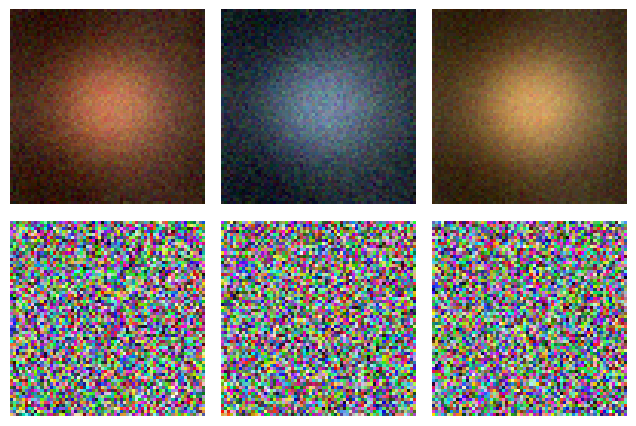

In [8]:
# Figure 6.8: 自然画像 (滑らかな空間相関) vs 一様ランダムノイズ画像
fig_6_8 = generate_figure_6_8(result_dirs=["result", "6/result"])
plt.show()


---
## 6.1.4 データ依存の基底関数 (Data-Dependent Basis Functions)

### 1. 手作業による特徴量設計からデータ駆動への転換
固定基底関数モデルの欠点を克服する伝統的なアプローチは、ドメイン専門家の知見に基づいて問題固有の特徴量（手作業の基底関数）を設計することでした。コンピュータビジョンにおける SIFT や HOG、音声認識における MFCC などがその代表例です。しかし、試行錯誤と職人芸に依存するこのアプローチは複雑な現実問題において性能の頭打ちを迎えました。

### 2. データ点に中心を置く動径基底関数 (Radial Basis Functions: RBF)
高次元空間全体を埋め尽くすのではなく、データ多様体に沿って基底関数を配置する最も直接的な方法は、**各訓練データ点 $\mathbf{x}_n$ の位置に基底関数の中心を置く**ことです：
$$
\phi_n(\mathbf{x}) = \exp\left( -\frac{\|\mathbf{x} - \mathbf{x}_n\|^2}{s^2} \right) \tag{6.6}
$$
ここで $s$ は基底関数の幅を制御する尺度パラメータです。
この手法は訓練データが存在する多様体の上に自動的に基底関数を集中させることができるため、事前の空間充填を回避できます。
しかし、このアプローチにも2つの重大な難点が存在します：
1. **計算量の問題**: 訓練データ数 $N$ が数百万〜数十億に達する大規模学習において、基底関数の数が $N$ 個となり、推論・学習の計算量とメモリ消費が爆発する。
2. **過適合の問題**: すべてのデータ点に局所関数を配置するため、慎重な正則化を行わないと深刻な過適合を引き起こす。

サポートベクトルマシン (SVM) は、訓練データの中から疎な部分集合（サポートベクトル）を自動選択することでこの問題を一部緩和しますが、依然として大規模データへのスケーラビリティには限界があります。

### 3. 深層ニューラルネットワークへのパラダイムシフト
これらの限界を真に打破したのが**ニューラルネットワーク (Neural Networks)** です：
ニューラルネットワークは、基底関数自身に**学習可能なパラメータ**を持たせます：
$$
z_j = h\left( \sum_{i=1}^D w_{ji} x_i + w_{j0} \right)
$$
入力データと目的変数の間の教師あり信号（損失関数の勾配）を通じて、誤差逆伝播法により**データ多様体と予測タスクに最も適した基底関数をエンドツーエンドで自動的に最適化**します。この強力な適応性こそが、固定基底関数の限界を乗り越え、現代の深層学習革命を駆動する本質的な原動力です。


In [9]:
# RBF データ依存基底関数による特徴写像の検証
np.random.seed(42)
X_demo = np.array([
    [0.0, 0.0],
    [1.0, 1.0],
    [-1.0, 1.0]
])

# 訓練データを中心とするRBF
rbf_model = RadialBasisFunctions(centers=X_demo, scale=1.5, include_bias=True)
Phi_demo = rbf_model.transform(X_demo)

print("=== データ依存 RBF 特徴行列 Phi (N=3, M=3+1 bias) ===")
print("特徴量形状:", Phi_demo.shape)
print("特徴行列:\n", np.round(Phi_demo, 4))

# 各中心における自己応答が 1.0 (exp(0) = 1) であることを確認
for i in range(3):
    assert np.isclose(Phi_demo[i, i + 1], 1.0)
assert np.allclose(Phi_demo[:, 0], 1.0)
print("\nRBF 基底関数: 数理的無矛盾性を確認しました！")


=== データ依存 RBF 特徴行列 Phi (N=3, M=3+1 bias) ===
特徴量形状: (3, 4)
特徴行列:
 [[1.     1.     0.4111 0.4111]
 [1.     0.4111 1.     0.169 ]
 [1.     0.4111 0.169  1.    ]]

RBF 基底関数: 数理的無矛盾性を確認しました！


---
## 6.1節のまとめ (Section 6.1 Summary)

本節では、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念』第6章「深層ニューラルネットワーク」の導入として、固定基底関数モデルの根本的限界を数理と可視化を通じて明らかにしました：

1. **次元の呪い (6.1.1節)**: 多項式モデルのパラメータ数は $O(D^M)$ で増加し、空間分割によるセル数は $K^D$ で指数爆発するため、高次元空間を固定基底関数で網羅することは不可能である。
2. **高次元空間の幾何学 (6.1.2節)**:
   - 超球の体積のほぼすべてが表面の薄い球殻に集中する ($1 - (1-\epsilon)^D \to 1$)。
   - ガウス分布の確率質量は原点ではなく、半径 $\hat{r} \approx \sqrt{D}\sigma$ の薄い球殻に集中する。
   - 次元数を増やすことで、低次元で重複していたクラスが線形分離可能になるという大きな利点も存在する。
3. **データ多様体 (6.1.3節)**: 実データは高次元空間全体を埋めるのではなく、はるかに低い内在的次元を持つ非線形多様体上に局在している（画像多様体の平行移動・回転自由度、自然画像の強い空間相関）。
4. **学習可能な基底関数への道 (6.1.4節)**: 手作業の特徴量設計や単純なデータ配置型 RBF の計算量・過適合の限界を克服するため、基底関数自体がパラメータを持ち、勾配降下法によってデータ多様体に適応する**多層・深層ニューラルネットワーク (Multilayer / Deep Neural Networks)** の導入が必然となる。
